In [133]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Подключаемся к базе SQLite
db_path = "../db/wikipedia.db"

## 1.1. Количество автомобилей в базе

In [134]:
with sqlite3.connect(db_path) as conn:
  # Загружаем данные
  query = "SELECT id, production_start_year, production_end_year, vehicle_class, body_style FROM vehicles"
  df = pd.read_sql(query, conn)
  num_vehicles = len(df)
  print(f"Общее количество автомобилей в базе: {num_vehicles}")

Общее количество автомобилей в базе: 9581


## 1.2. Распределение моделей по годам начала производства

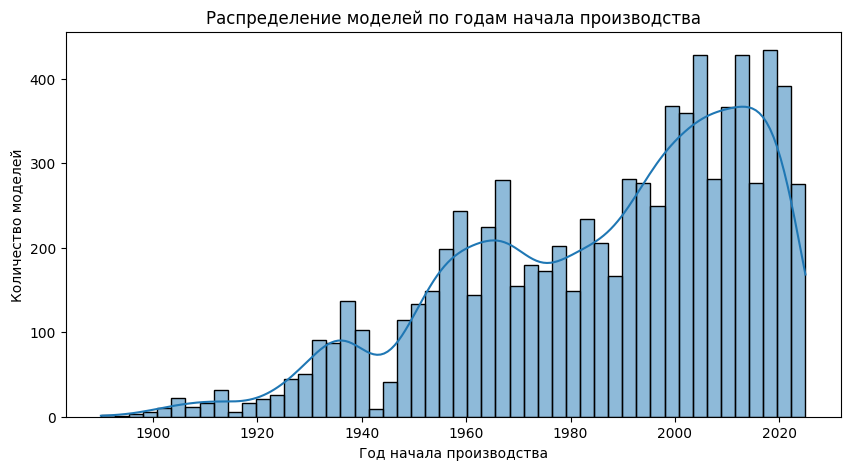

In [135]:
with sqlite3.connect(db_path) as conn:
  # Загружаем данные
  query = "SELECT id, production_start_year, production_end_year, vehicle_class, body_style FROM vehicles"
  df = pd.read_sql(query, conn)
  plt.figure(figsize=(10, 5))
  sns.histplot(df['production_start_year'].dropna(), bins=50, kde=True)
  #plt.xlim(1900, 2025)  # Устанавливаем границы оси X
  plt.xlabel("Год начала производства")
  plt.ylabel("Количество моделей")
  plt.title("Распределение моделей по годам начала производства")
  plt.show()

## 1.3. Распределение моделей по годам окончания производства

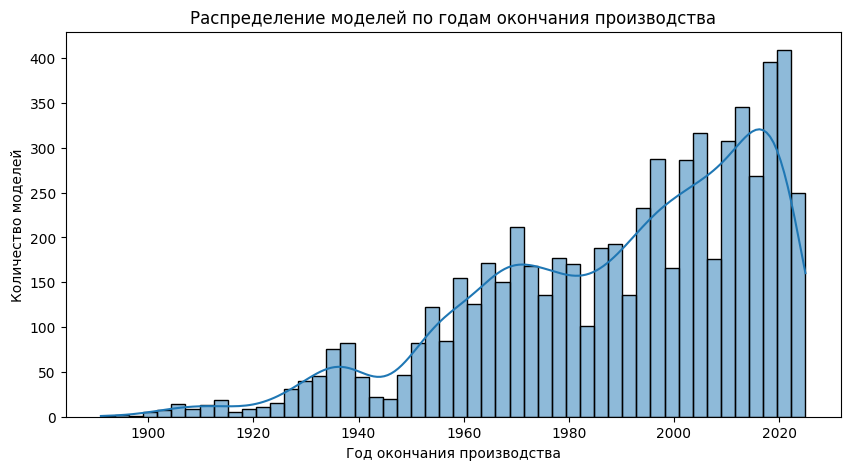

In [136]:
with sqlite3.connect(db_path) as conn:
  # Загружаем данные
  query = "SELECT id, production_start_year, production_end_year, vehicle_class, body_style FROM vehicles"
  df = pd.read_sql(query, conn)
plt.figure(figsize=(10, 5))
sns.histplot(df['production_end_year'].dropna(), bins=50, kde=True)
plt.xlabel("Год окончания производства")
plt.ylabel("Количество моделей")
plt.title("Распределение моделей по годам окончания производства")
plt.show()

## 1.4. Количество моделей по классам 

Всего количество классов автомобилей: 579


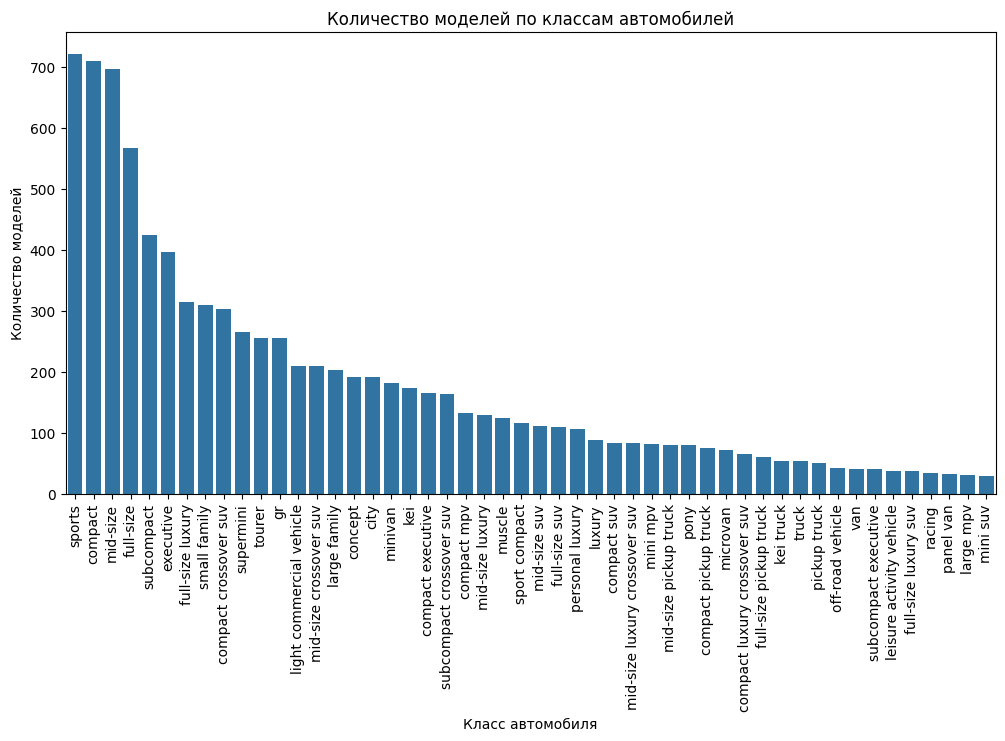

In [137]:
with sqlite3.connect(db_path) as conn:
  df = pd.read_sql("SELECT vehicle_class FROM vehicles", conn)

# Убираем NaN (если есть)
df = df.dropna()

# Разбиваем vehicle_class по `;` и преобразуем в длинный список
all_classes = df['vehicle_class'].str.replace('car', '').str.split(';').explode().str.strip()

# Считаем, сколько раз встречается каждый класс
class_counts = all_classes.value_counts()
print(f"Всего количество классов автомобилей: {len(class_counts.index)}")

# Только 10 самых частых классов
top_classes = class_counts.head(50)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=top_classes.index, y=top_classes.values)
plt.xticks(rotation=90)  # Поворачиваем подписи, если их много
plt.xlabel("Класс автомобиля")
plt.ylabel("Количество моделей")
plt.title("Количество моделей по классам автомобилей")
plt.show()

## 1.5. Количество моделей по типам кузова

Всего количество типов кузова: 1499


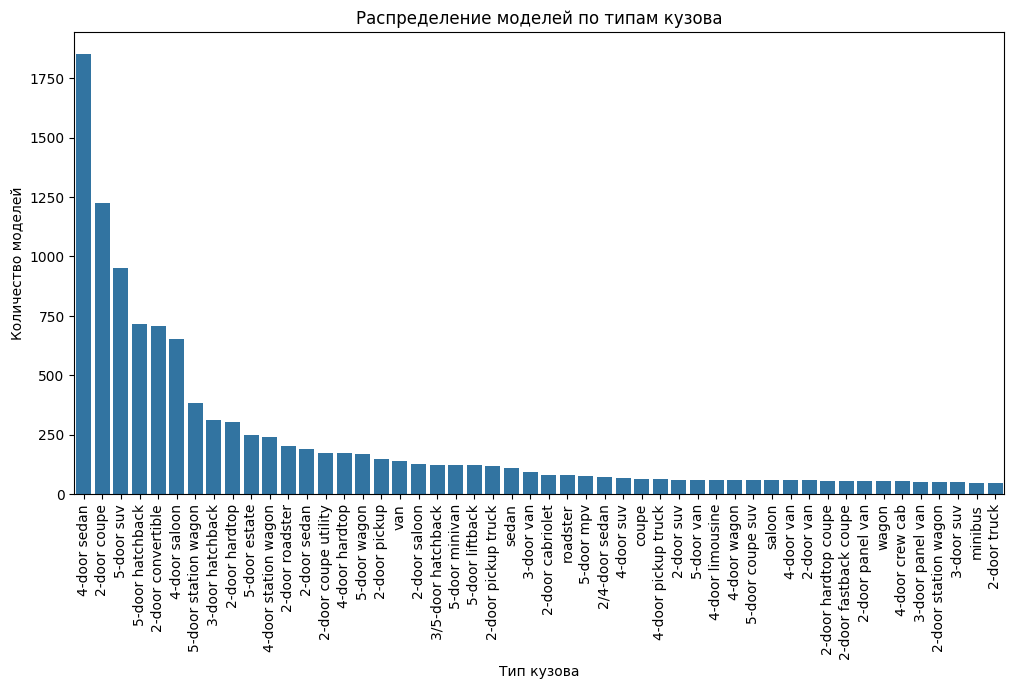

In [138]:
with sqlite3.connect(db_path) as conn:
  df = pd.read_sql("SELECT body_style FROM vehicles", conn)

# Убираем NaN (если есть)
df = df.dropna()

# Разбиваем vehicle_class по `;` и преобразуем в длинный список
all_body_style = df['body_style'].str.split(';').explode().str.strip()

# Считаем, сколько раз встречается каждый тип кузова
body_style_counts = all_body_style.value_counts()
print(f"Всего количество типов кузова: {len(body_style_counts.index)}")

# Только 50 самых частых классов
top_body_style = body_style_counts.head(50)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=top_body_style.index, y=top_body_style.values)
plt.xticks(rotation=90)  # Поворачиваем подписи, если их много
plt.xlabel("Тип кузова")
plt.ylabel("Количество моделей")
plt.title("Распределение моделей по типам кузова")
plt.show()

## 1.7. Тренды классов автомобилей по годам

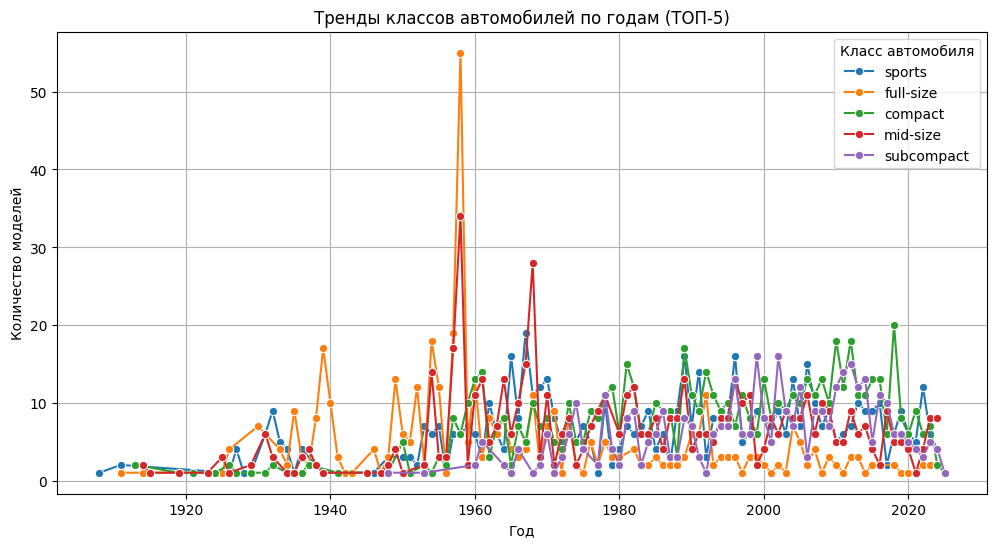

In [139]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT production_start_year, vehicle_class
    FROM vehicles
    WHERE production_start_year IS NOT NULL and vehicle_class IS NOT NULL
    """
    df_class_trends = pd.read_sql(query, conn)

# Разделяем vehicle_class по ";"
df_class_trends["vehicle_class"] = df_class_trends["vehicle_class"].str.split(";")

# "Разворачиваем" (explode) каждый класс в отдельные строки
df_class_trends = df_class_trends.explode("vehicle_class")

# Убираем лишние пробелы
df_class_trends["vehicle_class"] = df_class_trends["vehicle_class"].str.replace('car', '').str.strip()

# Группируем по годам и классам, считаем количество
df_class_trends = df_class_trends.groupby(["production_start_year", "vehicle_class"]).size().reset_index(name="count")

# ТОП-5 популярных классов
top5_classes = df_class_trends.groupby("vehicle_class")["count"].sum().nlargest(5).index
df_class_trends = df_class_trends[df_class_trends["vehicle_class"].isin(top5_classes)]

# Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_class_trends, x="production_start_year", y="count", hue="vehicle_class", marker="o")
plt.xlabel("Год")
plt.ylabel("Количество моделей")
plt.title("Тренды классов автомобилей по годам (ТОП-5)")
plt.legend(title="Класс автомобиля")
plt.grid(True)
plt.show()

## 1.8. Сравнение классов по десятилетиям

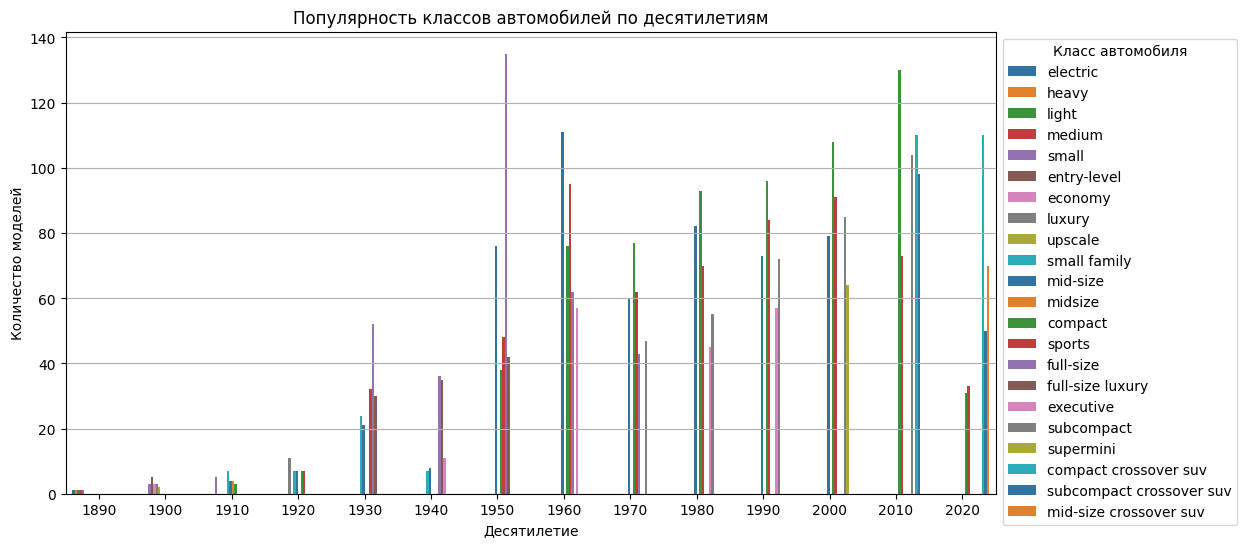

In [140]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT (production_start_year / 10) * 10 AS decade, vehicle_class
    FROM vehicles
    WHERE production_start_year IS NOT NULL and vehicle_class IS NOT NULL
    """
    df_decades = pd.read_sql(query, conn)

# Разделяем vehicle_class по ";"
df_decades["vehicle_class"] = df_decades["vehicle_class"].str.split(";")

# "Разворачиваем" (explode) каждый класс в отдельные строки
df_decades = df_decades.explode("vehicle_class")

# Убираем лишние пробелы
df_decades["vehicle_class"] = df_decades["vehicle_class"].str.replace('car', '').str.strip()

# Группируем по годам и классам, считаем количество
df_decades = df_decades.groupby(["decade", "vehicle_class"]).size().reset_index(name="count")

# Оставляем ТОП-5 классов по десятилетиям
df_decades["decade"] = df_decades["decade"].astype(int)
# Выбираем ТОП-5 классов по количеству моделей в каждом десятилетии
df_decades_top5 = (
    df_decades.sort_values(["decade", "count"], ascending=[True, False])
    .groupby("decade", as_index=False)
    .head(5)  # Выбираем 5 строк для каждого десятилетия
)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=df_decades_top5, x="decade", y="count", hue="vehicle_class", palette="tab10")
plt.xlabel("Десятилетие")
plt.ylabel("Количество моделей")
plt.title("Популярность классов автомобилей по десятилетиям")
plt.legend(title="Класс автомобиля", bbox_to_anchor=(1, 1))
plt.grid(axis="y")
plt.show()

## 2.1. Количество автомобилей с разными типами топлива

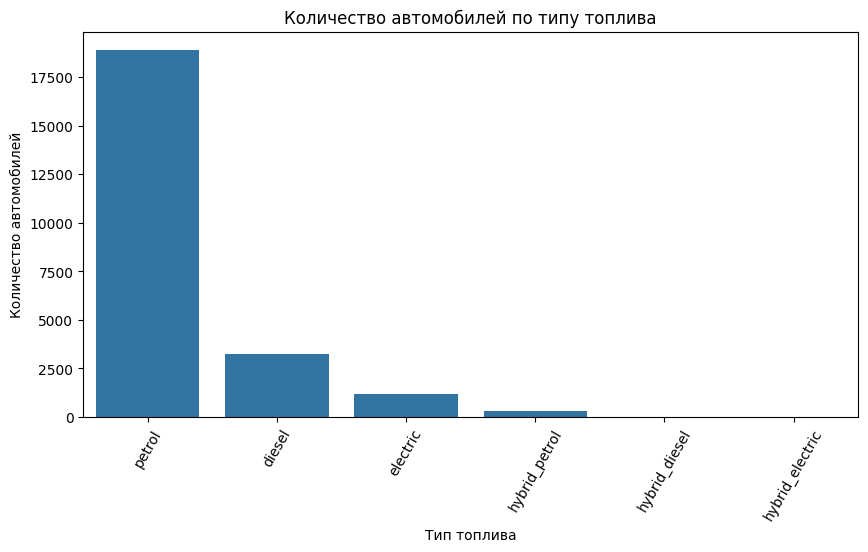

In [141]:
# Загружаем данные
with sqlite3.connect(db_path) as conn:
    df_engines = pd.read_sql("SELECT type_fuel FROM engines", conn)
# Убираем NaN
df_engines = df_engines.dropna()
# Считаем количество автомобилей для каждого типа топлива
fuel_counts = df_engines['type_fuel'].value_counts()
# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(x=fuel_counts.index, y=fuel_counts.values)
plt.xlabel("Тип топлива")
plt.ylabel("Количество автомобилей")
plt.title("Количество автомобилей по типу топлива")
plt.xticks(rotation=60)  # Поворачиваем подписи, если их много
plt.show()

## 2.2. Распределение объёмов двигателей

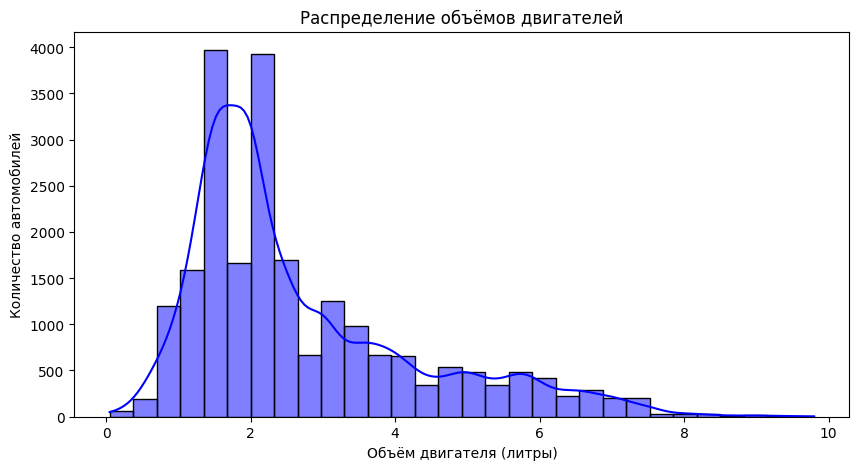

In [142]:
with sqlite3.connect(db_path) as conn:
    df_volumes = pd.read_sql("SELECT volume FROM engines", conn)

# Убираем NaN и выбросы (например, если объем больше 10 литров)
df_volumes = df_volumes.dropna()
df_volumes = df_volumes[(df_volumes['volume'] > 0) & (df_volumes['volume'] < 10)]  # Убираем ошибочные нули

# Визуализация
plt.figure(figsize=(10, 5))
sns.histplot(df_volumes['volume'], bins=30, kde=True, color="blue")
plt.xlabel("Объём двигателя (литры)")
plt.ylabel("Количество автомобилей")
plt.title("Распределение объёмов двигателей")
plt.show()

## 2.3. Зависимость мощности (power) от объёма двигателя (volume)

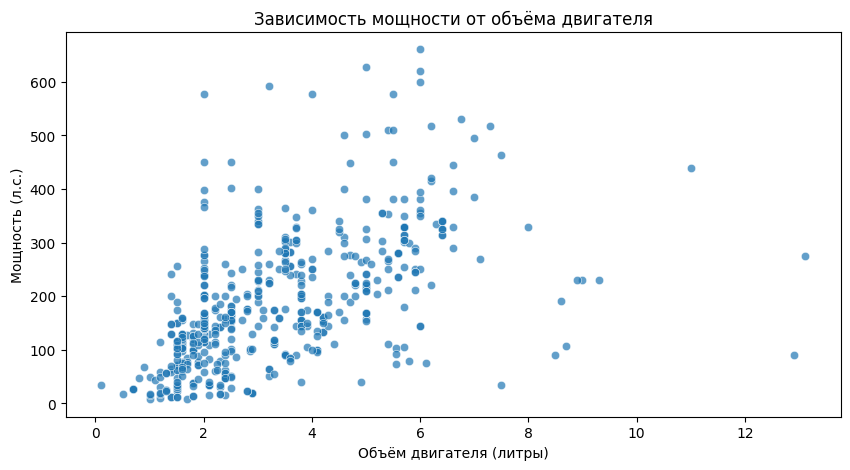

In [143]:
with sqlite3.connect(db_path) as conn:
    df_power_volume = pd.read_sql("SELECT volume, power FROM engines", conn)

# Убираем NaN и выбросы
df_power_volume = df_power_volume.dropna()
df_power_volume = df_power_volume[(df_power_volume['volume'] > 0) & (df_power_volume['volume'] < 20) & (df_power_volume['power'] > 0)]

# Визуализация
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df_power_volume['volume'], y=df_power_volume['power'], alpha=0.7)
plt.xlabel("Объём двигателя (литры)")
plt.ylabel("Мощность (л.с.)")
plt.title("Зависимость мощности от объёма двигателя")
plt.show()

## 2.4. ТОП-10 моделей с самыми мощными двигателями

In [144]:
query = """
SELECT v.model_name, v.production_start_year, e.volume, e.power
FROM engines e
JOIN vehicles v ON e.vehicle_id = v.id
WHERE e.power IS NOT NULL
ORDER BY e.power DESC
LIMIT 10;
"""

with sqlite3.connect(db_path) as conn:
    df_top_powerful = pd.read_sql(query, conn)

print(df_top_powerful)

                                  model_name  production_start_year  volume   power
0             Tatra 163 (Tatra Jamal Evo IV)                    NaN     NaN  1250.0
1              Jaguar Vision Gran Turismo SV                    NaN     NaN   874.0
2                                 M-Hero 917                 2023.0     NaN   805.0
3                                     IM LS6                 2023.0     NaN   776.0
4                                     IM LS6                 2023.0     NaN   776.0
5       Mercedes-Benz Vision EQ Silver Arrow                    NaN     NaN   740.0
6                  Vision Mercedes-Maybach 6                    NaN     NaN   738.0
7       Dodge Charger (2024) (Dodge Charger)                 2024.0     NaN   690.0
8         Hyundai Veloster (Veloster N ETCR)                 2011.0     NaN   670.0
9  Mercedes-Benz SL-Class (Fifth generation)                 2001.0     6.0   661.0


## 3.1. Какие типы трансмиссий наиболее популярны?

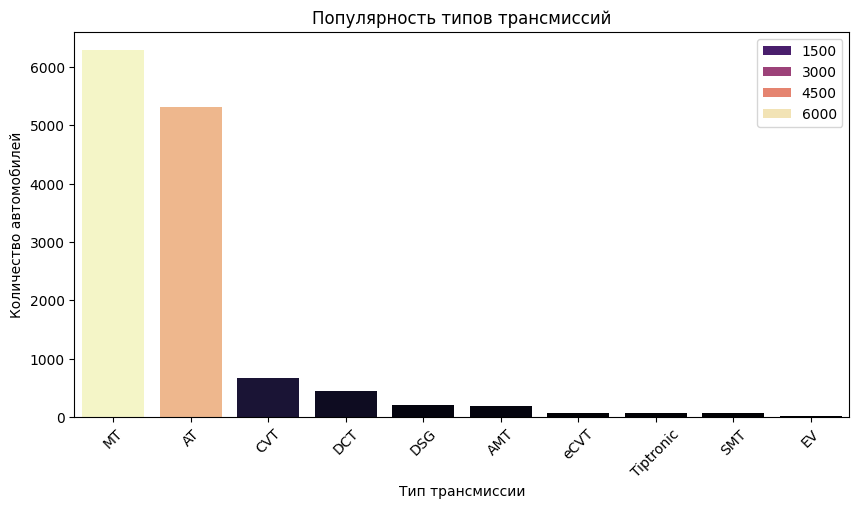

In [145]:
with sqlite3.connect(db_path) as conn:
    df_transmissions = pd.read_sql("SELECT type FROM transmissions", conn)

# Убираем NaN
df_transmissions = df_transmissions.dropna()

# Считаем количество автомобилей для каждого типа трансмиссии
transmission_counts = df_transmissions['type'].value_counts()

# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(x=transmission_counts.index, y=transmission_counts.values, hue=transmission_counts.values, palette="magma")
plt.xlabel("Тип трансмиссии")
plt.ylabel("Количество автомобилей")
plt.title("Популярность типов трансмиссий")
plt.xticks(rotation=45)  # Поворот подписей для удобства
plt.show()

## 3.2 Распределение автомобилей по количеству передач (speed)

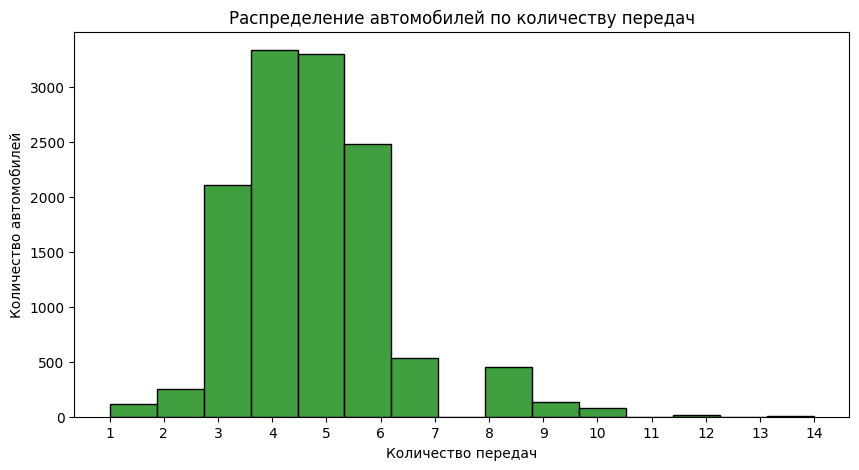

In [146]:
with sqlite3.connect(db_path) as conn:
    df_speeds = pd.read_sql("SELECT speed FROM transmissions", conn)

# Убираем NaN и выбросы (например, если число передач странное, вроде 0 или > 15)
df_speeds = df_speeds.dropna()
df_speeds = df_speeds[(df_speeds['speed'] > 0) & (df_speeds['speed'] <= 15)]

# Визуализация
plt.figure(figsize=(10, 5))
sns.histplot(df_speeds['speed'], bins=15, kde=False, color="green")
plt.xlabel("Количество передач")
plt.ylabel("Количество автомобилей")
plt.title("Распределение автомобилей по количеству передач")
plt.xticks(range(int(df_speeds['speed'].min()), int(df_speeds['speed'].max()) + 1))  # Указываем все возможные значения передач
plt.show()

## 3.3 График популярности типов трансмиссий по годам

   production_start_year type  count
0                   1898   MT      1
1                   1899   MT      1
2                   1900   MT      2
3                   1901   MT      3
4                   1904   MT      2


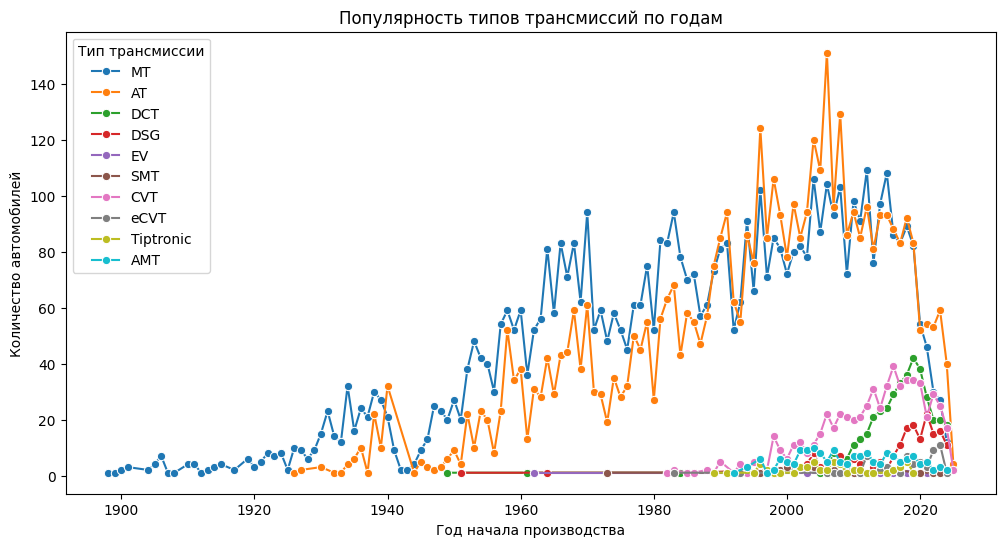

In [147]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT v.production_start_year, t.type
    FROM transmissions t
    JOIN vehicles v ON t.vehicle_id = v.id
    WHERE v.production_start_year IS NOT NULL
    """
    df_transmissions_years = pd.read_sql(query, conn)

# Убираем NaN и возможные некорректные года (например, < 1885)
df_transmissions_years = df_transmissions_years.dropna()

# Группируем данные: сколько раз встречается каждый тип трансмиссии по годам
df_counts = df_transmissions_years.groupby(['production_start_year', 'type']).size().reset_index(name="count")
print(df_counts.head())
# Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_counts, x="production_start_year", y="count", hue="type", marker="o", palette="tab10")
plt.xlabel("Год начала производства")
plt.ylabel("Количество автомобилей")
plt.title("Популярность типов трансмиссий по годам")
plt.legend(title="Тип трансмиссии")
plt.show()

## 3.4. Среднее количество передач по типам трансмиссий

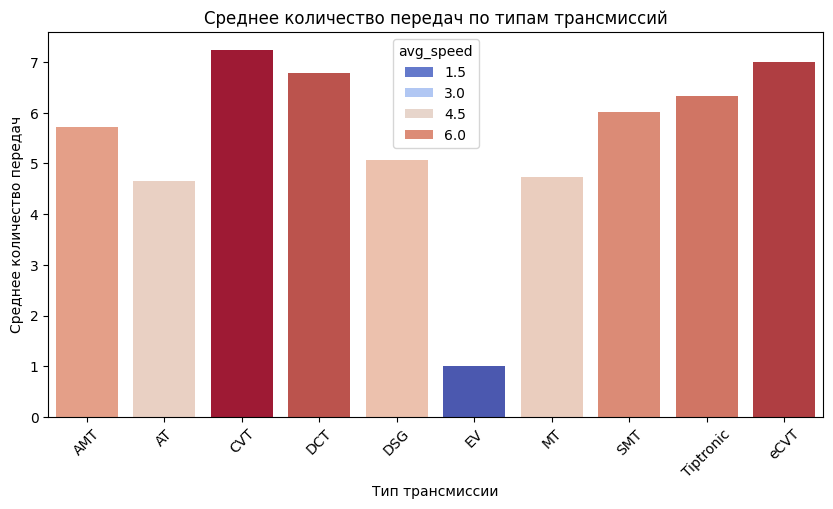

In [148]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT t.type, AVG(t.speed) as avg_speed
    FROM transmissions t
    WHERE t.speed IS NOT NULL AND t.speed > 0
    GROUP BY t.type
    """
    df_avg_speed = pd.read_sql(query, conn)

# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(data=df_avg_speed, x='type', y='avg_speed', hue='avg_speed', palette="coolwarm")
plt.xlabel("Тип трансмиссии")
plt.ylabel("Среднее количество передач")
plt.title("Среднее количество передач по типам трансмиссий")
plt.xticks(rotation=45)
plt.show()

## 4.1. Корреляция между габаритами автомобилей

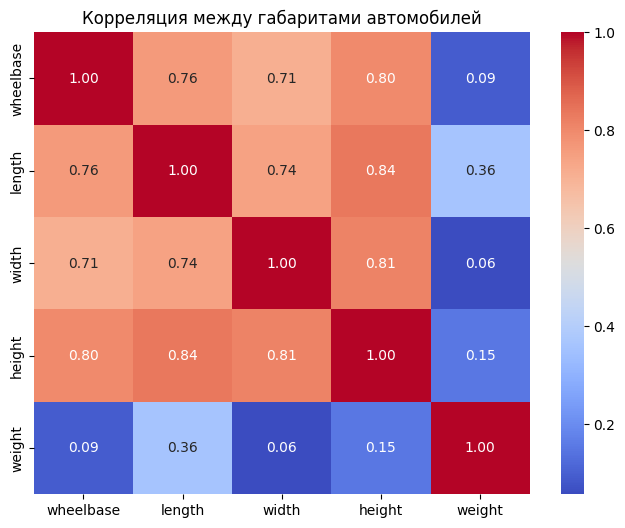

In [149]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT wheelbase, length, width, height, weight
    FROM vehicles
    WHERE wheelbase IS NOT NULL AND length IS NOT NULL AND width IS NOT NULL 
          AND height IS NOT NULL AND weight IS NOT NULL
    """
    df_dimensions = pd.read_sql(query, conn)

# Строим тепловую карту корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(df_dimensions.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция между габаритами автомобилей")
plt.show()

## 4.2. Зависимость массы автомобиля от его размеров

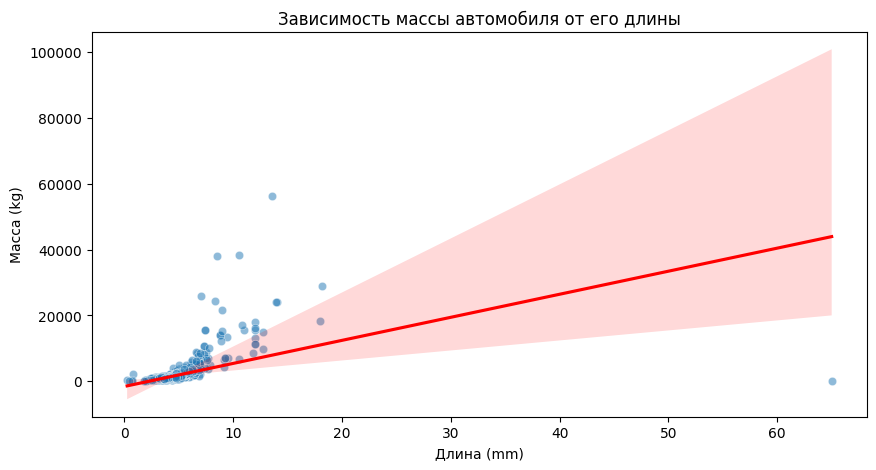

In [150]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT length, weight
    FROM vehicles
    WHERE length IS NOT NULL AND weight IS NOT NULL
    """
    df_dimensions = pd.read_sql(query, conn)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=df_dimensions['length'], y=df_dimensions['weight'], alpha=0.5)
sns.regplot(x=df_dimensions['length'], y=df_dimensions['weight'], scatter=False, color="red")  # Линия тренда
plt.xlabel("Длина (mm)")
plt.ylabel("Масса (kg)")
plt.title("Зависимость массы автомобиля от его длины")
plt.show()

## 4.3 Тренды изменения размеров автомобилей с годами

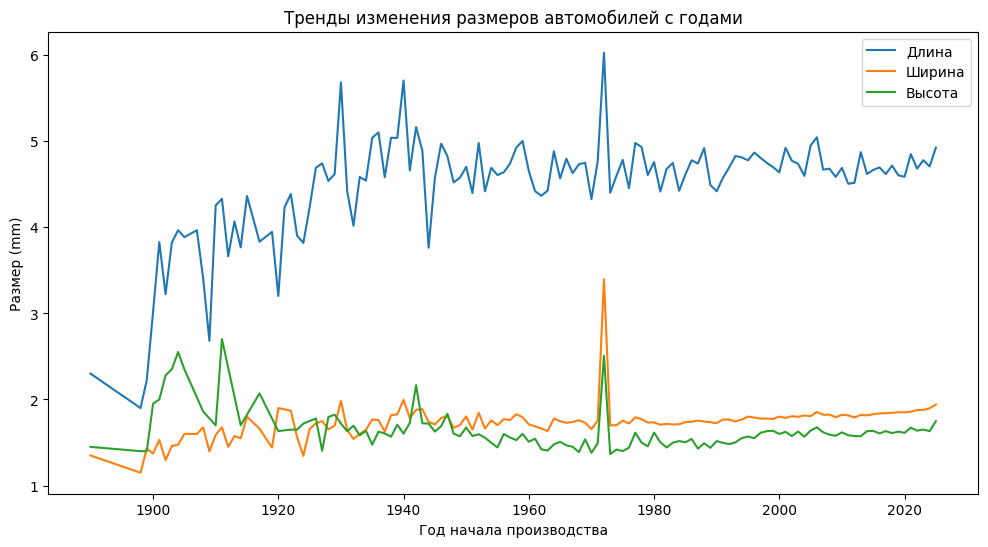

In [151]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT production_start_year, wheelbase, length, width, height
    FROM vehicles
    WHERE production_start_year IS NOT NULL
    """
    df_trends = pd.read_sql(query, conn)

# Группируем по годам, считаем средние размеры
df_trends = df_trends.groupby("production_start_year").mean().reset_index()

# Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_trends['production_start_year'], y=df_trends['length'], label="Длина")
sns.lineplot(x=df_trends['production_start_year'], y=df_trends['width'], label="Ширина")
sns.lineplot(x=df_trends['production_start_year'], y=df_trends['height'], label="Высота")
plt.xlabel("Год начала производства")
plt.ylabel("Размер (mm)")
plt.title("Тренды изменения размеров автомобилей с годами")
plt.legend()
plt.show()

## 5.1. В каких странах собирают больше всего автомобилей?

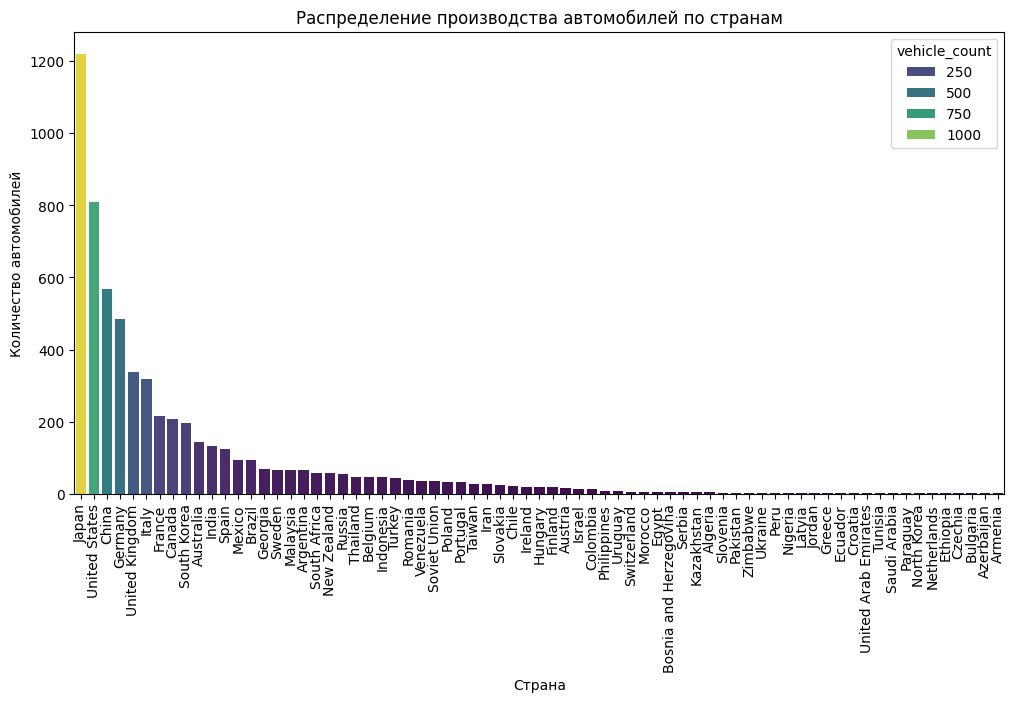

In [152]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT country, COUNT(vehicle_id) AS vehicle_count
    FROM assemblies
    GROUP BY country
    ORDER BY vehicle_count DESC
    """
    df_countries = pd.read_sql(query, conn)

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(data=df_countries, x="country", y="vehicle_count", hue="vehicle_count", palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("Страна")
plt.ylabel("Количество автомобилей")
plt.title("Распределение производства автомобилей по странам")
plt.show()

## 5.2. Как меняется количество сборочных заводов по годам?

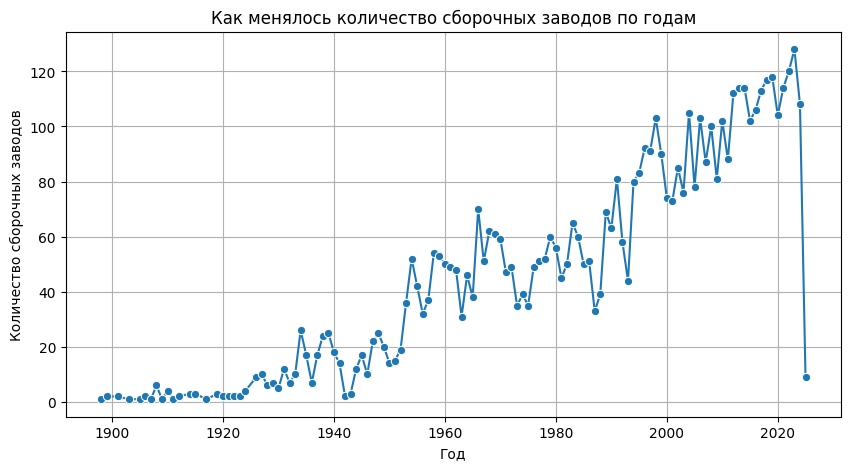

In [153]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT v.production_start_year, COUNT(a.vehicle_id) AS assembly_count
    FROM assemblies a
    JOIN vehicles v ON a.vehicle_id = v.id
    WHERE v.production_start_year IS NOT NULL
    GROUP BY v.production_start_year
    ORDER BY v.production_start_year
    """
    df_assembly_trends = pd.read_sql(query, conn)

# Визуализация трендов
plt.figure(figsize=(10, 5))
sns.lineplot(x=df_assembly_trends["production_start_year"], y=df_assembly_trends["assembly_count"], marker="o")
plt.xlabel("Год")
plt.ylabel("Количество сборочных заводов")
plt.title("Как менялось количество сборочных заводов по годам")
plt.grid(True)
plt.show()

## 5.2. Таблица ТОП-стран по годам

In [154]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT v.production_start_year, a.country, COUNT(a.vehicle_id) AS vehicle_count
    FROM assemblies a
    JOIN vehicles v ON a.vehicle_id = v.id
    WHERE v.production_start_year IS NOT NULL
    GROUP BY v.production_start_year, a.country
    ORDER BY v.production_start_year, vehicle_count DESC
    """
    df_top_countries = pd.read_sql(query, conn)

# Выбираем ТОП-5 стран по каждому году
df_top_countries["rank"] = df_top_countries.groupby("production_start_year")["vehicle_count"].rank(method="dense", ascending=False)
df_top_countries_top5 = df_top_countries[df_top_countries["rank"] <= 5]

# Выводим таблицу
df_pivot = df_top_countries_top5.pivot_table(index="production_start_year", columns="rank", values="country", aggfunc=lambda x: ', '.join(x))
df_pivot.tail(10)

rank,1.0,2.0,3.0,4.0,5.0
production_start_year,,,,,
2016,China,Japan,South Korea,Germany,United States
2017,China,Japan,United States,Germany,Spain
2018,China,"United States, Germany",Japan,South Korea,"Spain, India"
2019,China,United States,Germany,Japan,India
2020,China,Japan,"United States, Germany",South Korea,"Spain, Italy, India"
2021,China,"Japan, Germany",United States,"South Korea, India",France
2022,China,Japan,United States,Germany,Italy
2023,China,Japan,"United States, Germany","Mexico, India",South Korea
2024,China,Germany,"United States, Mexico",South Korea,"Japan, India, France"


## 6.1. Топ производителей по количеству моделей

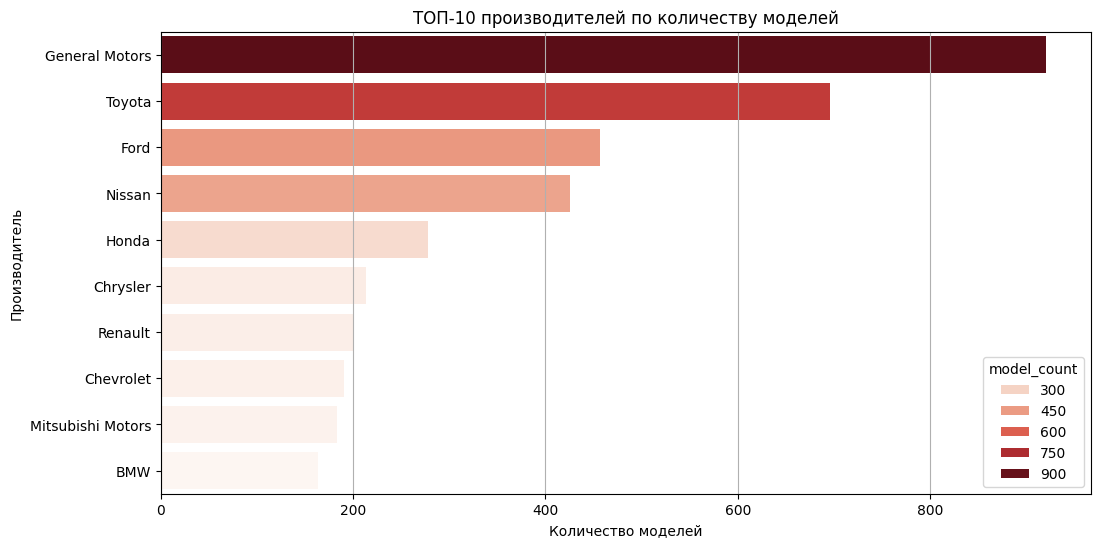

In [155]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT m.company, COUNT(DISTINCT v.model_name) AS model_count
    FROM manufacturers m
    JOIN vehicles v ON m.vehicle_id = v.id
    GROUP BY m.company
    ORDER BY model_count DESC
    LIMIT 10
    """
    df_top_manufacturers = pd.read_sql(query, conn)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_manufacturers, x="model_count", y="company", hue="model_count", palette="Reds")
plt.xlabel("Количество моделей")
plt.ylabel("Производитель")
plt.title("ТОП-10 производителей по количеству моделей")
plt.grid(axis="x")
plt.show()

## 6.2. Тренды: какие компании чаще выпускают новые модели?

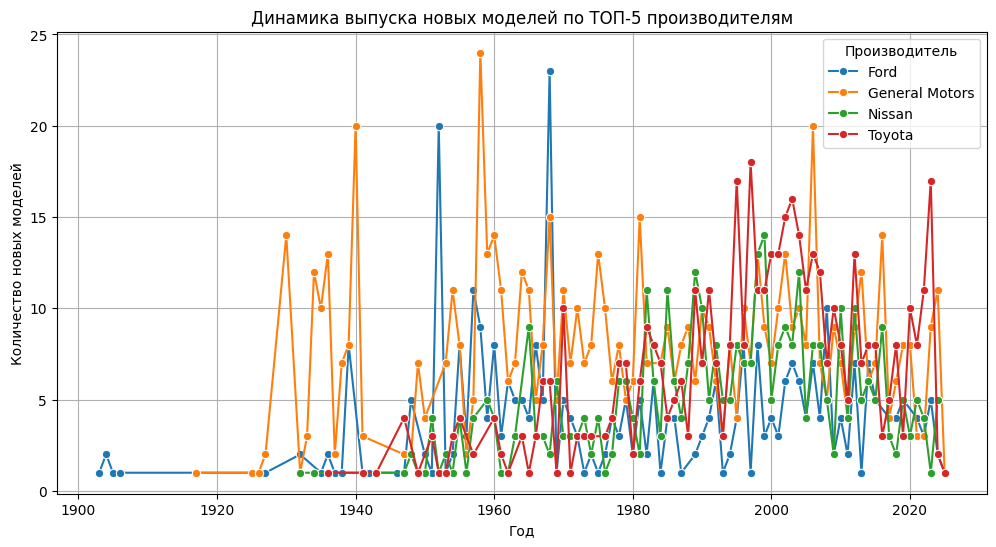

In [157]:
with sqlite3.connect(db_path) as conn:
    query = """
    SELECT v.production_start_year, m.company, COUNT(DISTINCT v.model_name) AS model_count
    FROM manufacturers m
    JOIN vehicles v ON m.vehicle_id = v.id
    WHERE v.production_start_year IS NOT NULL
    GROUP BY v.production_start_year, m.company
    """
    df_trends = pd.read_sql(query, conn)

# Определяем ТОП-5 производителей по общему количеству моделей
top5_companies = df_trends.groupby("company")["model_count"].sum().nlargest(4).index

# Оставляем только эти компании
df_trends_top5 = df_trends[df_trends["company"].isin(top5_companies)]

# Визуализация
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends_top5, x="production_start_year", y="model_count", hue="company", marker="o")
plt.xlabel("Год")
plt.ylabel("Количество новых моделей")
plt.title("Динамика выпуска новых моделей по ТОП-5 производителям")
plt.legend(title="Производитель")
plt.grid(True)
plt.show()